<a href="https://colab.research.google.com/github/ayatayoub20/intermediate-machine-learning-projects/blob/main/Introduction%20to%20Deep%20Learning/Neural_Network_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

In [48]:
# import data

reg_url = '/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week11/Data/train.csv'
df= pd.read_csv(reg_url)

# # drop car name columns
# df_reg = df_reg.drop(columns='car name')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [49]:
# check missing values and duplicates
print('missing values', df.info())
print('\nduplicated rows', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [50]:
# split data
X = df.drop(columns=['SalePrice', 'Id'])
y = np.log1p(df['SalePrice'])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
num_processor = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_processor = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore')
)

preprocessor = make_column_transformer(
    (num_processor, make_column_selector(dtype_include=np.number)),
    (cat_processor, make_column_selector(dtype_exclude=np.number))
)

In [53]:
X_train_tf = preprocessor.fit_transform(X_train)
X_test_tf = preprocessor.transform(X_test)

input_shape = X_train_tf.shape[1]
input_shape

285

#Model 1 (Baseline)

In [54]:
def build_model_1():

    model = Sequential()

    model.add(Dense(
        10,
        input_dim=input_shape,
        activation='relu'
    ))

    model.add(Dense(
        10,
        activation='relu'
    ))

    model.add(Dense(
        1,
        activation='linear'
    ))

    model.compile(
        loss='mse',
        optimizer='adam',
        metrics=['mae']
    )

    return model

In [55]:
model_1 = build_model_1()

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │         2,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,981 (11.64 KB)

 Trainable params: 2,981 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [57]:
history_1 = model_1.fit(
    X_train_tf,
    y_train,
    validation_split=0.2,
    epochs=100,
    verbose=0,
    callbacks=[early_stop]
)

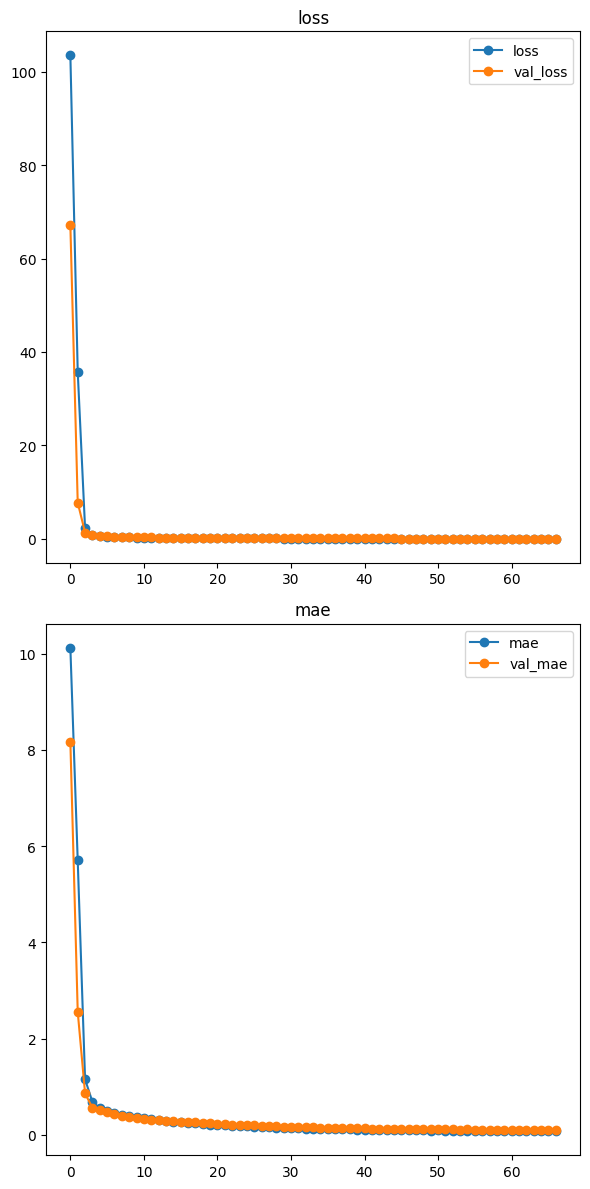

In [58]:
plot_history(history_1);

In [59]:
# evaluate model

pred_1_log = model_1.predict(X_test_tf)

pred_1 = np.expm1(pred_1_log)
y_test_original = np.expm1(y_test)

rmse_1 = np.sqrt(mean_squared_error(y_test_original, pred_1))
mae_1 = mean_absolute_error(y_test_original, pred_1)
r2_1 = r2_score(y_test_original, pred_1)

print(f'Model 1 RMSE: {rmse_1}')
print(f'Model 1 MAE: {mae_1}')
print(f'Model 1 R2: {r2_1}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Model 1 RMSE: 30934.183274025658
Model 1 MAE: 18795.87150845463
Model 1 R2: 0.8752434161229848


#Model 2: Larger Model

In [71]:
# Model 2 (Larger Model)

def build_model_2():

    model = Sequential()

    model.add(Dense(
        64,
        input_dim=input_shape,
        activation='relu'
    ))

    model.add(Dense(
        32,
        activation='relu'
    ))

    model.add(Dense(
        16,
        activation='relu'
    ))

    model.add(Dense(
        1,
        activation='linear'
    ))

    model.compile(
        loss='mse',
        optimizer='adam',
        metrics=['mae']
    )

    return model

In [72]:
model_2 = build_model_2()

model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 64)             │        18,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,929 (81.75 KB)

 Trainable params: 20,929 (81.75 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
early_stop_2 = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [74]:
history_2 = model_2.fit(
    X_train_tf,
    y_train,
    validation_split=0.2,
    epochs=100,
    verbose=0,
    callbacks=[early_stop_2]
)

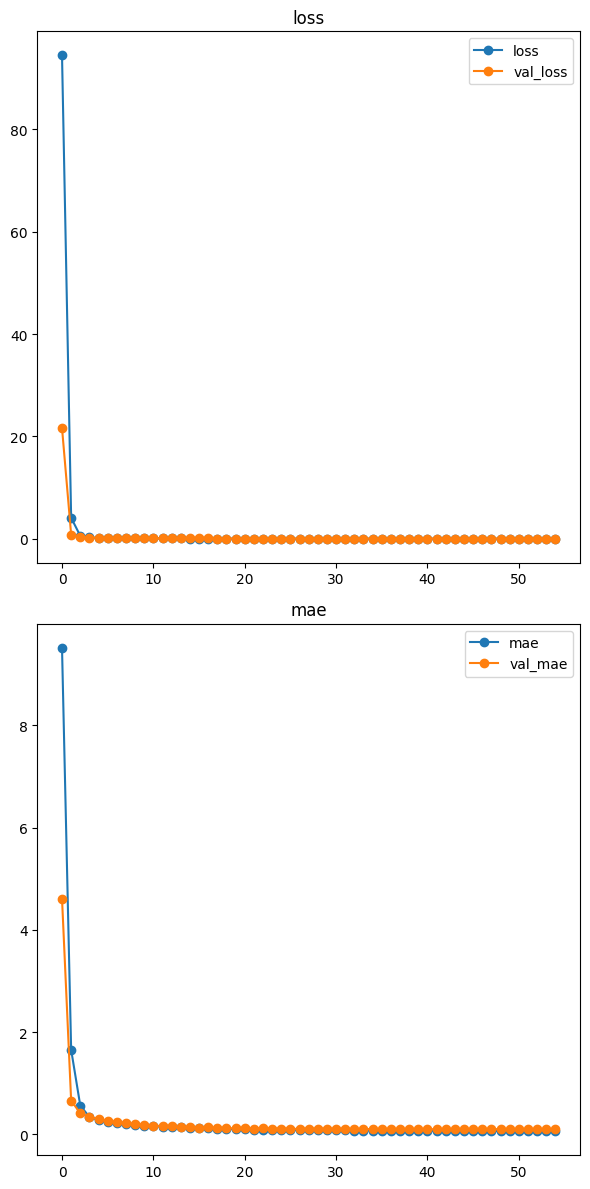

In [75]:
plot_history(history_2);

In [76]:
pred_2_log = model_2.predict(X_test_tf)

pred_2 = np.expm1(pred_2_log)
y_test_original = np.expm1(y_test)

rmse_2 = np.sqrt(mean_squared_error(y_test_original, pred_2))
mae_2 = mean_absolute_error(y_test_original, pred_2)
r2_2 = r2_score(y_test_original, pred_2)

print(f'Model 2 RMSE: {rmse_2}')
print(f'Model 2 MAE: {mae_2}')
print(f'Model 2 R2: {r2_2}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Model 2 RMSE: 26602.29280905107
Model 2 MAE: 17728.124357876717
Model 2 R2: 0.9077376941237012


In [69]:
pred_2[:10]

array([[ 65007.695],
       [ 30888.158],
       [ 13548.654],
       [ 24354.883],
       [ 46100.1  ],
       [156590.27 ],
       [ 28897.596],
       [ 45762.68 ],
       [139644.69 ],
       [ 43835.285]], dtype=float32)

In [77]:
# Model 3: Regularized Model

def build_model_3():

    model = Sequential()

    model.add(Dense(
        128,
        input_dim=input_shape,
        activation='relu'
    ))

    model.add(Dropout(0.2))

    model.add(Dense(
        64,
        activation='relu'
    ))

    model.add(Dropout(0.2))

    model.add(Dense(
        32,
        activation='relu'
    ))

    model.add(Dense(
        1,
        activation='linear'
    ))

    model.compile(
        loss='mse',
        optimizer='adam',
        metrics=['mae']
    )

    return model

In [78]:
model_3 = build_model_3()

model_3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │        36,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,977 (183.50 KB)

 Trainable params: 46,977 (183.50 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
early_stop_3 = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [80]:
history_3 = model_3.fit(
    X_train_tf,
    y_train,
    validation_split=0.2,
    epochs=300,
    verbose=0,
    callbacks=[early_stop_3]
)

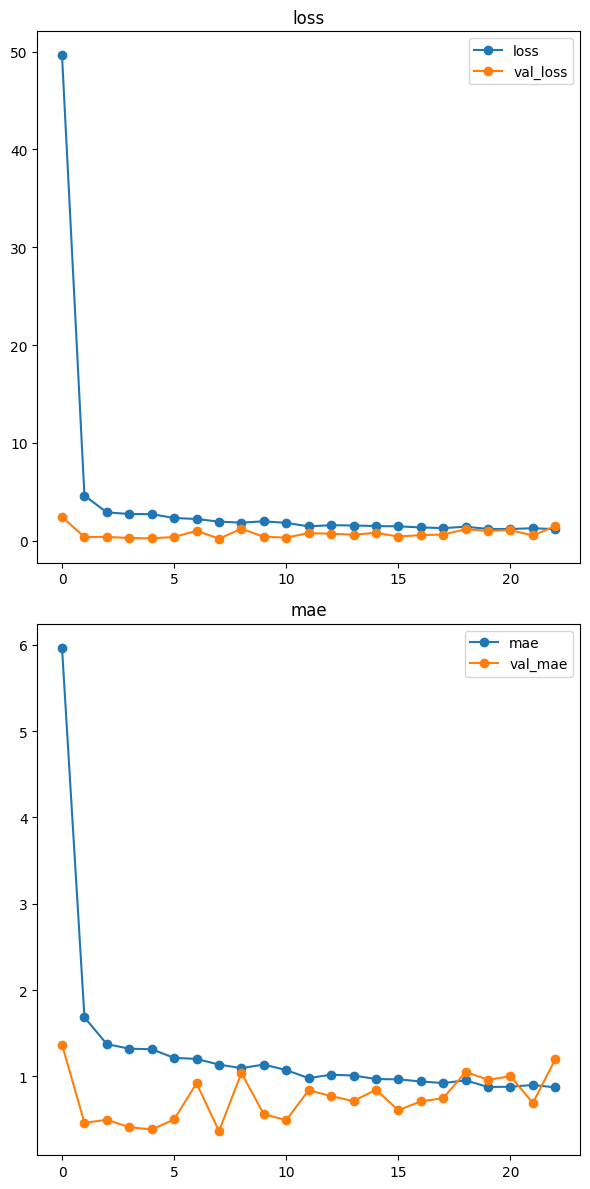

In [81]:
plot_history(history_3);

In [82]:
pred_3_log = model_3.predict(X_test_tf)

pred_3 = np.expm1(pred_3_log)
y_test_original = np.expm1(y_test)

rmse_3 = np.sqrt(mean_squared_error(y_test_original, pred_3))
mae_3 = mean_absolute_error(y_test_original, pred_3)
r2_3 = r2_score(y_test_original, pred_3)

print(f'Model 3 RMSE: {rmse_3}')
print(f'Model 3 MAE: {mae_3}')
print(f'Model 3 R2: {r2_3}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Model 3 RMSE: 76994.39916670595
Model 3 MAE: 55736.36438489941
Model 3 R2: 0.22713358690177254


Three neural network models were evaluated. Model 2 achieved the best performance with an R² score of approximately 0.91 and the lowest prediction error. Model 1 performed reasonably well but was less accurate. Model 3 included dropout regularization; however, it underfit the data and produced significantly worse results. Therefore, Model 2 was selected as the final model.